# Notebook 11: Policy Gradient Methods — REINFORCE

**Series:** Reinforcement Learning Basics (11/20)

---

## 1. Why Policy Gradients?

Value-based methods learn $Q(s,a)$ then derive a policy. Policy gradient methods **directly** parameterize the policy $\pi_\theta(a|s)$.

| Advantage | Explanation |
|-----------|-------------|
| **Stochastic policies** | Can naturally represent mixed strategies |
| **Continuous actions** | Output parameters of a distribution (e.g., Gaussian) |
| **Convergence** | Guaranteed to converge to a local optimum |

## 2. Policy Parameterizations

**Softmax (discrete):**
$$\pi_\theta(a|s) = \frac{\exp(\theta^\top \mathbf{x}(s,a))}{\sum_b \exp(\theta^\top \mathbf{x}(s,b))}$$

**Gaussian (continuous):**
$$\pi_\theta(a|s) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(a - \mu_\theta(s))^2}{2\sigma^2}\right)$$

## 3. Policy Gradient Theorem

**Objective:** $J(\theta) = V^{\pi_\theta}(s_0) = \mathbb{E}_{\pi_\theta}\left[\sum_t \gamma^t R_{t+1}\right]$

$$\boxed{\nabla_\theta J(\theta) = \mathbb{E}_{\pi_\theta}\left[\sum_t \gamma^t \nabla_\theta \log \pi_\theta(A_t|S_t) \, Q^{\pi_\theta}(S_t, A_t)\right]}$$

### Derivation (Key Steps)

**Log-derivative trick:** $\nabla_\theta \pi_\theta = \pi_\theta \nabla_\theta \log \pi_\theta$

This allows us to write the gradient as an expectation under $\pi_\theta$, which we can estimate with samples!

## 4. REINFORCE Algorithm

Replace $Q^{\pi_\theta}(S_t, A_t)$ with the sample return $G_t$:

$$\theta \leftarrow \theta + \alpha \gamma^t G_t \nabla_\theta \log \pi_\theta(A_t|S_t)$$

## 5. REINFORCE with Baseline

$$\theta \leftarrow \theta + \alpha \gamma^t (G_t - b(S_t)) \nabla_\theta \log \pi_\theta(A_t|S_t)$$

**Common baseline:** $b(S_t) = V(S_t)$

**Why baseline helps:** Reduces variance without changing the expected gradient:
$$\mathbb{E}_{\pi_\theta}[b(S_t) \nabla_\theta \log \pi_\theta(A_t|S_t)] = 0$$

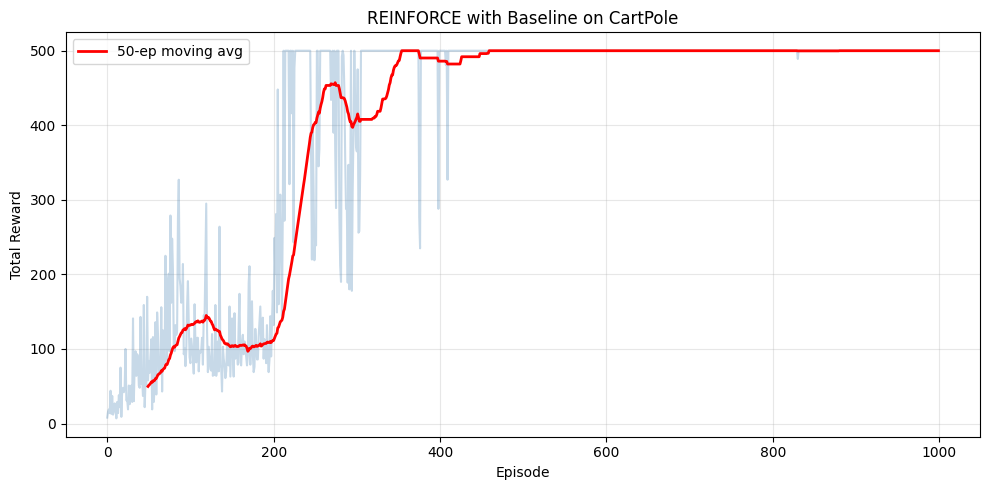

Last 100 episodes avg: 500.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# CartPole Environment (simplified)
# ============================================
class CartPole:
    def __init__(self):
        self.gravity = 9.8
        self.masscart = 1.0
        self.masspole = 0.1
        self.total_mass = self.masscart + self.masspole
        self.length = 0.5
        self.polemass_length = self.masspole * self.length
        self.force_mag = 10.0
        self.tau = 0.02
        self.theta_threshold = 12 * np.pi / 180
        self.x_threshold = 2.4

    def reset(self):
        self.state = np.random.uniform(-0.05, 0.05, 4)
        return self.state.copy()

    def step(self, action):
        x, x_dot, theta, theta_dot = self.state
        force = self.force_mag if action == 1 else -self.force_mag
        costheta = np.cos(theta)
        sintheta = np.sin(theta)
        temp = (force + self.polemass_length * theta_dot**2 * sintheta) / self.total_mass
        thetaacc = (self.gravity * sintheta - costheta * temp) / (
            self.length * (4/3 - self.masspole * costheta**2 / self.total_mass))
        xacc = temp - self.polemass_length * thetaacc * costheta / self.total_mass
        x += self.tau * x_dot
        x_dot += self.tau * xacc
        theta += self.tau * theta_dot
        theta_dot += self.tau * thetaacc
        self.state = np.array([x, x_dot, theta, theta_dot])
        done = (abs(x) > self.x_threshold or abs(theta) > self.theta_threshold)
        reward = 1.0 if not done else 0.0
        return self.state.copy(), reward, done

# ============================================
# REINFORCE with Baseline
# ============================================
class PolicyNetwork:
    def __init__(self, n_features=4, n_actions=2, lr=0.01):
        self.theta = np.zeros((n_features, n_actions))
        self.lr = lr

    def softmax(self, state):
        logits = state @ self.theta
        logits -= np.max(logits)
        exp_logits = np.exp(logits)
        return exp_logits / np.sum(exp_logits)

    def choose_action(self, state):
        probs = self.softmax(state)
        return np.random.choice(len(probs), p=probs)

    def update(self, states, actions, advantages):
        for s, a, adv in zip(states, actions, advantages):
            probs = self.softmax(s)
            grad_log = -probs.copy()
            grad_log[a] += 1  # ∇log π = (1(a) - π(a))
            self.theta += self.lr * adv * np.outer(s, grad_log)

class ValueBaseline:
    def __init__(self, n_features=4, lr=0.01):
        self.w = np.zeros(n_features)
        self.lr = lr

    def predict(self, state):
        return state @ self.w

    def update(self, states, returns):
        for s, G in zip(states, returns):
            self.w += self.lr * (G - self.predict(s)) * s

# Train
env = CartPole()
policy = PolicyNetwork(lr=0.002)
baseline = ValueBaseline(lr=0.01)
gamma = 0.99

episode_rewards = []
for ep in range(1000):
    state = env.reset()
    states, actions, rewards = [], [], []
    for _ in range(500):
        action = policy.choose_action(state)
        next_state, reward, done = env.step(action)
        states.append(state)
        actions.append(action)
        rewards.append(reward)
        state = next_state
        if done:
            break

    # Compute returns
    G = 0
    returns = []
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)

    # Compute advantages
    advantages = [G - baseline.predict(s) for G, s in zip(returns, states)]

    # Update
    policy.update(states, actions, advantages)
    baseline.update(states, returns)
    episode_rewards.append(sum(rewards))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, alpha=0.3, color='steelblue')
smoothed = np.convolve(episode_rewards, np.ones(50)/50, mode='valid')
plt.plot(range(49, len(episode_rewards)), smoothed, 'r-', linewidth=2, label='50-ep moving avg')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('REINFORCE with Baseline on CartPole')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Last 100 episodes avg: {np.mean(episode_rewards[-100:]):.1f}")

## Summary

| Concept | Formula |
|---------|---------|
| **Policy Gradient Theorem** | $\nabla J(\theta) = \mathbb{E}[\sum_t \gamma^t \nabla \log \pi_\theta(A_t|S_t) Q^\pi(S_t,A_t)]$ |
| **REINFORCE** | $\theta \leftarrow \theta + \alpha \gamma^t G_t \nabla \log \pi_\theta(A_t|S_t)$ |
| **With Baseline** | $\theta \leftarrow \theta + \alpha \gamma^t (G_t - b(S_t)) \nabla \log \pi_\theta(A_t|S_t)$ |

**Next:** Notebook 12 — Actor-Critic Methods